In [121]:
import pandas as pd
import numpy as np
from pandas_datareader import data as pdr
import matplotlib.pyplot as plt

# 1. Data Acquisition & Preprocessing
Extracts and merges financial and macroeconomic data from EIA and FRED via external APIs.


### 1.1 EIA Monthly Data
- Fetches monthly oil fundamentals (e.g., OPEC capacity, OECD stocks) using the EIA API.

In [122]:
import pandas as pd
import requests
#  provided API Key
API_KEY = "HfP5BbvdMePabqVydR7tA6XWdG7OXnvI1uPBYx3m"

# 1. Define your updated function (if you haven't already run it)
def fetch_multiple_eia_data(base_url, params):
    try:
        print(f"--- Connecting to EIA API... ---")
        response = requests.get(base_url, params=params)
        response.raise_for_status()
        
        json_data = response.json()
        if 'response' in json_data and 'data' in json_data['response']:
            df = pd.DataFrame(json_data['response']['data'])
            
            # Convert types
            df['Date'] = pd.to_datetime(df['period'])
            df['value'] = pd.to_numeric(df['value'], errors='coerce')
            
            # Pivot columns
            df_pivot = df.pivot_table(index='Date', columns='seriesId', values='value')
            print(f"SUCCESS: Downloaded {len(df_pivot)} rows x {len(df_pivot.columns)} columns.")
            return df_pivot
        else:
            print("ERROR: Unexpected API format.")
            return None
    except Exception as e:
        print(f"FAILED: {e}")
        return None

# 2. Define the parameters with FIXED keys
series_list = [
    "COPC_OPEC", "COPRPUS", "COPS_OPEC", "CORIPUS",
    "PAPR_NONOPEC", "PAPR_OECD", "PAPR_OPEC",
    "PASC_OECD_T3", "PATC_NON_OECD",
    "T3_STCHANGE_NOECD", "T3_STCHANGE_OOECD"
]

params = {
    "api_key": API_KEY,   # <--- PASTE YOUR KEY HERE
    "frequency": "monthly",
    
    # FIX 1: Use specific key for data request
    "data[0]": "value",
    
    # FIX 2: Manually format the sort keys
    "sort[0][column]": "period",
    "sort[0][direction]": "asc",
    
    # FIX 3: Flatten the facet key explicitly for the list
    "facets[seriesId][]": series_list, 
    
    "start": "1993-01",
    "end": "2025-12",
    "offset": 0,
    "length": 5000
}

# 3. Fetch
base_url = "https://api.eia.gov/v2/steo/data/"
df = fetch_multiple_eia_data(base_url, params)

if df is not None:
    display(df.tail())

--- Connecting to EIA API... ---
SUCCESS: Downloaded 396 rows x 11 columns.


seriesId,COPC_OPEC,COPRPUS,COPS_OPEC,CORIPUS,PAPR_NONOPEC,PAPR_OECD,PAPR_OPEC,PASC_OECD_T3,PATC_NON_OECD,T3_STCHANGE_NOECD,T3_STCHANGE_OOECD
Date,,,,,,,,,,,
2025-08-01,32.140,13.810121,4.225,16.942258,74.028929,36.899229,33.723800,2853.585525,57.733805,-2.292838,-0.890419
2025-09-01,32.298,13.838779,3.168,16.464433,73.960359,36.766059,34.976200,2858.306844,58.522291,-3.872965,-0.003467
2025-10-01,32.440,13.870431,3.655,15.525774,73.827207,36.741307,34.652800,2820.301078,57.397048,-6.067862,0.708710
2025-11-01,32.280,13.770278,3.645,16.442500,73.921262,37.029477,34.490896,2861.337198,58.455518,-2.770205,-0.730480
2025-12-01,32.270,13.849107,3.515,16.876484,73.416085,37.074592,34.649777,2882.907258,59.087965,-2.139431,-0.467572


In [123]:
# Remove the 'seriesId' label from the top of the columns
df.columns.name = None

# Check the result
display(df.head())

,COPC_OPEC,COPRPUS,COPS_OPEC,CORIPUS,PAPR_NONOPEC,PAPR_OECD,PAPR_OPEC,PASC_OECD_T3,PATC_NON_OECD,T3_STCHANGE_NOECD,T3_STCHANGE_OOECD
Date,,,,,,,,,,,
1993-01-01,26.924623,6.961007,3.472345,12.938,42.381897,20.988856,25.407278,NaN,23.259579,NaN,NaN
1993-02-01,26.924623,6.942592,3.331733,12.865,42.260014,20.865008,25.547890,NaN,23.260107,NaN,NaN
1993-03-01,26.924623,6.974128,3.941320,13.200,42.213345,20.997839,24.938303,NaN,23.259745,NaN,NaN
1993-04-01,26.924623,6.881308,4.488239,13.538,42.025591,20.875101,24.391384,NaN,23.100834,NaN,NaN
1993-05-01,26.924623,6.846920,4.314518,13.829,41.962095,20.851220,24.565105,NaN,23.100178,NaN,NaN


In [124]:
df = df.dropna()
df.head()

,COPC_OPEC,COPRPUS,COPS_OPEC,CORIPUS,PAPR_NONOPEC,PAPR_OECD,PAPR_OPEC,PASC_OECD_T3,PATC_NON_OECD,T3_STCHANGE_NOECD,T3_STCHANGE_OOECD
Date,,,,,,,,,,,
2003-02-01,28.209000,5.782863,2.364945,14.381,50.572317,23.764914,28.735148,2394.414000,30.708553,0.295634,1.369643
2003-03-01,27.399329,5.803461,0.957693,14.933,50.407735,23.617457,29.375879,2463.397002,30.374890,2.080385,-1.772806
2003-04-01,26.383232,5.725816,0.820811,15.575,50.062831,23.097990,28.582918,2493.210998,29.941029,0.686065,-0.284933
2003-05-01,26.939523,5.663475,1.185702,15.910,49.877436,22.851393,28.720351,2541.263000,30.425602,1.007573,-0.476290
2003-06-01,27.177749,5.659077,2.138374,15.620,49.815246,22.646539,28.074057,2584.821001,30.827331,2.690327,-0.737567


### 1.2 EIA Long-term Data
- Fetches quarterly/yearly metrics (e.g., FOREX) and aligns them to the monthly timeline using forward-fill.

In [125]:
# 2. Define the parameters with FIXED keys
series_list2 = ["FOREX_WORLD"]

params2 = {
    "api_key": API_KEY,   # <--- PASTE YOUR KEY HERE
    "frequency": "quarterly",
    
    # FIX 1: Use specific key for data request
    "data[0]": "value",
    
    # FIX 2: Manually format the sort keys
    "sort[0][column]": "period",
    "sort[0][direction]": "asc",
    
    # FIX 3: Flatten the facet key explicitly for the list
    "facets[seriesId][]": series_list2, 
    
    "start": "2003",
    "end": "2025",
    "offset": 0,
    "length": 5000
}

# 3. Fetch
base_url = "https://api.eia.gov/v2/steo/data/"
df2 = fetch_multiple_eia_data(base_url, params2)

if df2 is not None:
    display(df2.head())

--- Connecting to EIA API... ---
SUCCESS: Downloaded 89 rows x 1 columns.


/var/folders/yx/89px_c7d6_d78x4s5ng8zpt80000gn/T/ipykernel_46276/802829068.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['period'])


seriesId,FOREX_WORLD
Date,
2003-01-01,106.696386
2003-04-01,102.741155
2003-07-01,102.703215
2003-10-01,99.620601
2004-01-01,97.571849


In [126]:
df2 = df2.reindex(df.index, method='ffill')
df2.head()

seriesId,FOREX_WORLD
Date,
2003-02-01,106.696386
2003-03-01,106.696386
2003-04-01,102.741155
2003-05-01,102.741155
2003-06-01,102.741155


In [127]:
# get yearly data
series_list3 = [
            "RGDPQ_NONOECD",
            "RGDPQ_OECD"
]

params3 = {
    "api_key": API_KEY,   # <--- PASTE YOUR KEY HERE
    "frequency": "annual",
    
    # FIX 1: Use specific key for data request
    "data[0]": "value",
    
    # FIX 2: Manually format the sort keys
    "sort[0][column]": "period",
    "sort[0][direction]": "asc",
    
    # FIX 3: Flatten the facet key explicitly for the list
    "facets[seriesId][]": series_list3, 
    
    "start": "2003",
    "end": "2025",
    "offset": 0,
    "length": 5000
}

# 3. Fetch
base_url = "https://api.eia.gov/v2/steo/data/"
df3 = fetch_multiple_eia_data(base_url, params3)

if df3 is not None:
    display(df3.head())

--- Connecting to EIA API... ---
SUCCESS: Downloaded 23 rows x 2 columns.


seriesId,RGDPQ_NONOECD,RGDPQ_OECD
Date,,
2003-01-01,49.414608,80.423044
2004-01-01,53.307931,83.033196
2005-01-01,57.192212,85.490466
2006-01-01,61.819320,88.241849
2007-01-01,67.245280,90.656417


In [128]:
df3 = df3.reindex(df.index, method='ffill')
df3.head()


seriesId,RGDPQ_NONOECD,RGDPQ_OECD
Date,,
2003-02-01,49.414608,80.423044
2003-03-01,49.414608,80.423044
2003-04-01,49.414608,80.423044
2003-05-01,49.414608,80.423044
2003-06-01,49.414608,80.423044


In [129]:


# Combine all 3 dataframe from EIA data
df_eia = pd.concat([df, df2, df3], axis=1)

# 3. Check the result
print(df_eia.head())
print(df_eia.shape)

            COPC_OPEC   COPRPUS  COPS_OPEC  CORIPUS  PAPR_NONOPEC  PAPR_OECD  \
Date                                                                           
2003-02-01  28.209000  5.782863   2.364945   14.381     50.572317  23.764914   
2003-03-01  27.399329  5.803461   0.957693   14.933     50.407735  23.617457   
2003-04-01  26.383232  5.725816   0.820811   15.575     50.062831  23.097990   
2003-05-01  26.939523  5.663475   1.185702   15.910     49.877436  22.851393   
2003-06-01  27.177749  5.659077   2.138374   15.620     49.815246  22.646539   

            PAPR_OPEC  PASC_OECD_T3  PATC_NON_OECD  T3_STCHANGE_NOECD  \
Date                                                                    
2003-02-01  28.735148   2394.414000      30.708553           0.295634   
2003-03-01  29.375879   2463.397002      30.374890           2.080385   
2003-04-01  28.582918   2493.210998      29.941029           0.686065   
2003-05-01  28.720351   2541.263000      30.425602           1.007573   
2

### 1.3 FRED Macro Data
- Downloads macroeconomic indicators (e.g., WTI crude prices) from the FRED API and handles missing values.

In [130]:
import requests
import pandas as pd
from functools import reduce

def fetch_fred_data(api_key, series_ids, start_date, end_date):
    """
    Fetches multiple series from FRED API v2 and merges them into one DataFrame.
    """
    base_url = "https://api.stlouisfed.org/fred/series/observations"
    data_frames = []
    
    print(f"--- Starting FRED API calls for {len(series_ids)} series ---")
    
    for sid in series_ids:
        # Params required by FRED API
        # Documentation: https://fred.stlouisfed.org/docs/api/fred/series_observations.html
        params = {
            'series_id': sid,
            'api_key': api_key,
            'file_type': 'json',
            'observation_start': start_date,
            'observation_end': end_date,
            'frequency': 'm'  # Ensure monthly
        }
        
        try:
            response = requests.get(base_url, params=params)
            response.raise_for_status()
            json_data = response.json()
            
            # Observations are in ['observations'] key
            if 'observations' in json_data:
                df = pd.DataFrame(json_data['observations'])
                
                # Keep only date and value
                df = df[['date', 'value']]
                
                # Convert types
                df['date'] = pd.to_datetime(df['date'])
                df['value'] = pd.to_numeric(df['value'], errors='coerce')
                
                # Rename value column to the Series ID
                df.rename(columns={'value': sid}, inplace=True)
                
                # Set index
                df.set_index('date', inplace=True)
                
                data_frames.append(df)
                print(f"SUCCESS: {sid}")
            else:
                print(f"ERROR: No observations found for {sid}")
                
        except Exception as e:
            print(f"FAILED: {sid} - {e}")

    # Merge all dataframes on Date
    if data_frames:
        print("--- Merging data... ---")
        # specific merge to handle potential missing dates efficiently
        df_final = reduce(lambda left, right: pd.merge(left, right, on='date', how='outer'), data_frames)
        df_final.sort_index(inplace=True)
        return df_final
    else:
        return None

# ==========================================
# 1. SETUP
# ==========================================
FRED_API_KEY = "98fa1c5a055178d7bae03332fc80d151"  # <--- REPLACE THIS WITH YOUR KEY

series_to_fetch = [
    "CPIENGSL", "CAPG211S", "CAPUTLG211S", 
    "IPG211S", "IPG211111CN", "INDPRO", 
    "IPN213111N", "PCU211211","WTISPLC"
]

# ==========================================
# 2. RUN
# ==========================================
df_fred = fetch_fred_data(FRED_API_KEY, series_to_fetch, "2003-01-01", "2025-12-31")

if df_fred is not None:
    display(df_fred.head())
    display(df_fred.tail())

--- Starting FRED API calls for 9 series ---
SUCCESS: CPIENGSL
SUCCESS: CAPG211S
SUCCESS: CAPUTLG211S
SUCCESS: IPG211S
SUCCESS: IPG211111CN
SUCCESS: INDPRO
SUCCESS: IPN213111N
SUCCESS: PCU211211
SUCCESS: WTISPLC
--- Merging data... ---


,CPIENGSL,CAPG211S,CAPUTLG211S,IPG211S,IPG211111CN,INDPRO,IPN213111N,PCU211211,WTISPLC
date,,,,,,,,,
2003-01-01,133.5,64.3248,93.2932,60.0106,88.4513,91.2361,88.2043,152.5,32.94
2003-02-01,140.8,64.3670,93.6644,60.2889,88.8760,91.3445,91.6739,170.2,35.87
2003-03-01,143.9,64.4263,92.9996,59.9162,89.1924,91.1044,93.3167,220.0,33.55
2003-04-01,136.5,64.4983,92.3483,59.5631,87.9987,90.5617,96.8014,150.2,28.25
2003-05-01,129.4,64.5757,90.7450,58.5992,87.0407,90.5370,102.3041,152.7,28.14


,CPIENGSL,CAPG211S,CAPUTLG211S,IPG211S,IPG211111CN,INDPRO,IPN213111N,PCU211211,WTISPLC
date,,,,,,,,,
2025-08-01,276.734,156.7588,96.5092,151.2866,NaN,101.6247,96.4551,167.434,64.86
2025-09-01,280.700,157.1187,96.5775,151.7413,NaN,101.7059,97.2862,163.566,63.96
2025-10-01,NaN,157.4851,95.6944,150.7043,NaN,101.2570,100.4551,157.562,60.89
2025-11-01,284.648,157.8572,95.3837,150.5701,NaN,101.3775,101.4003,159.742,60.06
2025-12-01,285.624,158.2326,95.2549,150.7243,NaN,101.6296,99.9723,172.006,57.97


In [131]:
df_fred=df_fred.dropna()
df_fred.tail()

,CPIENGSL,CAPG211S,CAPUTLG211S,IPG211S,IPG211111CN,INDPRO,IPN213111N,PCU211211,WTISPLC
date,,,,,,,,,
2020-12-01,205.670,135.6681,88.7582,120.4165,169.6635,98.3630,68.1227,129.3,47.02
2021-01-01,212.470,135.4099,89.8520,121.6685,169.2416,98.8822,74.9339,140.8,52.00
2021-02-01,219.242,135.1751,79.9949,108.1331,150.8145,95.6149,79.9490,189.1,59.04
2021-03-01,229.617,134.9727,90.7083,122.4314,165.8403,98.3856,80.7785,164.0,62.33
2021-04-01,227.255,134.8131,91.7871,123.7410,165.4243,98.5587,84.7118,153.0,61.72


### 1.4 Data Merging & Slicing
- Combines EIA and FRED data, calculates the target variable (next month's price), and splits the dataset into **Train**, **Validation**, and **Test** sets.

In [132]:
data =pd.concat([df_eia, df_fred], axis=1,join='inner')
display(data.head())
display(data.tail())
print(data.shape)

,COPC_OPEC,COPRPUS,COPS_OPEC,CORIPUS,PAPR_NONOPEC,PAPR_OECD,PAPR_OPEC,PASC_OECD_T3,PATC_NON_OECD,T3_STCHANGE_NOECD,...,RGDPQ_OECD,CPIENGSL,CAPG211S,CAPUTLG211S,IPG211S,IPG211111CN,INDPRO,IPN213111N,PCU211211,WTISPLC
2003-02-01,28.209000,5.782863,2.364945,14.381,50.572317,23.764914,28.735148,2394.414000,30.708553,0.295634,...,80.423044,140.8,64.3670,93.6644,60.2889,88.8760,91.3445,91.6739,170.2,35.87
2003-03-01,27.399329,5.803461,0.957693,14.933,50.407735,23.617457,29.375879,2463.397002,30.374890,2.080385,...,80.423044,143.9,64.4263,92.9996,59.9162,89.1924,91.1044,93.3167,220.0,33.55
2003-04-01,26.383232,5.725816,0.820811,15.575,50.062831,23.097990,28.582918,2493.210998,29.941029,0.686065,...,80.423044,136.5,64.4983,92.3483,59.5631,87.9987,90.5617,96.8014,150.2,28.25
2003-05-01,26.939523,5.663475,1.185702,15.910,49.877436,22.851393,28.720351,2541.263000,30.425602,1.007573,...,80.423044,129.4,64.5757,90.7450,58.5992,87.0407,90.5370,102.3041,152.7,28.14
2003-06-01,27.177749,5.659077,2.138374,15.620,49.815246,22.646539,28.074057,2584.821001,30.827331,2.690327,...,80.423044,129.8,64.6517,90.9473,58.7990,86.9731,90.6527,103.9168,169.3,30.72


,COPC_OPEC,COPRPUS,COPS_OPEC,CORIPUS,PAPR_NONOPEC,PAPR_OECD,PAPR_OPEC,PASC_OECD_T3,PATC_NON_OECD,T3_STCHANGE_NOECD,...,RGDPQ_OECD,CPIENGSL,CAPG211S,CAPUTLG211S,IPG211S,IPG211111CN,INDPRO,IPN213111N,PCU211211,WTISPLC
2020-12-01,29.94,11.188200,5.785,14.139806,63.936375,31.062312,29.3748,3026.009711,50.502157,-1.895836,...,104.693363,205.670,135.6681,88.7582,120.4165,169.6635,98.3630,68.1227,129.3,47.02
2021-01-01,29.71,11.155578,5.505,14.541839,64.345679,31.115694,29.4936,3035.446340,50.742987,-0.874384,...,111.278703,212.470,135.4099,89.8520,121.6685,169.2416,98.8822,74.9339,140.8,52.00
2021-02-01,30.20,9.930583,6.415,12.370929,61.608374,28.351145,29.0693,2966.362920,52.051124,0.938638,...,111.278703,219.242,135.1751,79.9949,108.1331,150.8145,95.6149,79.9490,189.1,59.04
2021-03-01,30.30,11.375774,6.405,14.387129,64.691088,31.236008,29.1816,2913.889210,51.857907,-0.058464,...,111.278703,229.617,134.9727,90.7083,122.4314,165.8403,98.3856,80.7785,164.0,62.33
2021-04-01,30.29,11.355340,6.405,15.162167,64.839706,30.840456,29.2573,2910.250995,52.230755,1.207781,...,111.278703,227.255,134.8131,91.7871,123.7410,165.4243,98.5587,84.7118,153.0,61.72


(219, 23)


In [133]:
data["forecast"]= data["WTISPLC"].shift(-1)
data=data.dropna()
if data.isna().any().any():
    print("Yes, there are missing values.")
else:
    print("No missing values found.")
display(data.head())
display(data.tail())

No missing values found.


,COPC_OPEC,COPRPUS,COPS_OPEC,CORIPUS,PAPR_NONOPEC,PAPR_OECD,PAPR_OPEC,PASC_OECD_T3,PATC_NON_OECD,T3_STCHANGE_NOECD,...,CPIENGSL,CAPG211S,CAPUTLG211S,IPG211S,IPG211111CN,INDPRO,IPN213111N,PCU211211,WTISPLC,forecast
2003-02-01,28.209000,5.782863,2.364945,14.381,50.572317,23.764914,28.735148,2394.414000,30.708553,0.295634,...,140.8,64.3670,93.6644,60.2889,88.8760,91.3445,91.6739,170.2,35.87,33.55
2003-03-01,27.399329,5.803461,0.957693,14.933,50.407735,23.617457,29.375879,2463.397002,30.374890,2.080385,...,143.9,64.4263,92.9996,59.9162,89.1924,91.1044,93.3167,220.0,33.55,28.25
2003-04-01,26.383232,5.725816,0.820811,15.575,50.062831,23.097990,28.582918,2493.210998,29.941029,0.686065,...,136.5,64.4983,92.3483,59.5631,87.9987,90.5617,96.8014,150.2,28.25,28.14
2003-05-01,26.939523,5.663475,1.185702,15.910,49.877436,22.851393,28.720351,2541.263000,30.425602,1.007573,...,129.4,64.5757,90.7450,58.5992,87.0407,90.5370,102.3041,152.7,28.14,30.72
2003-06-01,27.177749,5.659077,2.138374,15.620,49.815246,22.646539,28.074057,2584.821001,30.827331,2.690327,...,129.8,64.6517,90.9473,58.7990,86.9731,90.6527,103.9168,169.3,30.72,30.76


,COPC_OPEC,COPRPUS,COPS_OPEC,CORIPUS,PAPR_NONOPEC,PAPR_OECD,PAPR_OPEC,PASC_OECD_T3,PATC_NON_OECD,T3_STCHANGE_NOECD,...,CPIENGSL,CAPG211S,CAPUTLG211S,IPG211S,IPG211111CN,INDPRO,IPN213111N,PCU211211,WTISPLC,forecast
2020-11-01,29.91,11.224665,5.990,14.123700,64.022472,31.001720,29.1424,3100.085010,49.970578,-0.831854,...,197.017,135.9416,88.5437,120.3677,170.8845,97.0816,60.7168,119.6,40.94,47.02
2020-12-01,29.94,11.188200,5.785,14.139806,63.936375,31.062312,29.3748,3026.009711,50.502157,-1.895836,...,205.670,135.6681,88.7582,120.4165,169.6635,98.3630,68.1227,129.3,47.02,52.00
2021-01-01,29.71,11.155578,5.505,14.541839,64.345679,31.115694,29.4936,3035.446340,50.742987,-0.874384,...,212.470,135.4099,89.8520,121.6685,169.2416,98.8822,74.9339,140.8,52.00,59.04
2021-02-01,30.20,9.930583,6.415,12.370929,61.608374,28.351145,29.0693,2966.362920,52.051124,0.938638,...,219.242,135.1751,79.9949,108.1331,150.8145,95.6149,79.9490,189.1,59.04,62.33
2021-03-01,30.30,11.375774,6.405,14.387129,64.691088,31.236008,29.1816,2913.889210,51.857907,-0.058464,...,229.617,134.9727,90.7083,122.4314,165.8403,98.3856,80.7785,164.0,62.33,61.72


In [134]:
# Slicing datasets
data.index = data.index.to_period('M')
train_data = data[: int(data.shape[0] * 0.80)]
vald_data = data[int(0.80 * data.shape[0]) : int(0.90 * data.shape[0])]
test_data = data[int(0.90 * data.shape[0]) : int(data.shape[0])]

print("--- Dataset Ranges ---")
print(f"Train Data: {train_data.index.min()} to {train_data.index.max()} (Length: {len(train_data)})")
print(f"Vald Data:  {vald_data.index.min()} to {vald_data.index.max()} (Length: {len(vald_data)})")
print(f"Test Data:  {test_data.index.min()} to {test_data.index.max()} (Length: {len(test_data)})")

print("\n--- Column Counts ---")
print("Train Columns:\n", train_data.count())

--- Dataset Ranges ---
Train Data: 2003-02 to 2017-07 (Length: 174)
Vald Data:  2017-08 to 2019-05 (Length: 22)
Test Data:  2019-06 to 2021-03 (Length: 22)

--- Column Counts ---
Train Columns:
 COPC_OPEC            174
COPRPUS              174
COPS_OPEC            174
CORIPUS              174
PAPR_NONOPEC         174
PAPR_OECD            174
PAPR_OPEC            174
PASC_OECD_T3         174
PATC_NON_OECD        174
T3_STCHANGE_NOECD    174
T3_STCHANGE_OOECD    174
FOREX_WORLD          174
RGDPQ_NONOECD        174
RGDPQ_OECD           174
CPIENGSL             174
CAPG211S             174
CAPUTLG211S          174
IPG211S              174
IPG211111CN          174
INDPRO               174
IPN213111N           174
PCU211211            174
WTISPLC              174
forecast             174
dtype: int64


# 2. HMM Discretization & Model Training
Converts continuous time-series data into discrete market states and learns the causal structure.

In [135]:
!pip install --upgrade pip
!pip install hmmlearn

### 2.1 Gaussian HMM Training
- Computes simple returns and trains 3-state Hidden Markov Models (HMM) for each economic variable.

In [136]:
# ==========================================
# PART 1: Gaussian HMM Training & Parameters
# ==========================================
import numpy as np
import pandas as pd
from hmmlearn import hmm

# 1. Prepare Data (Continuous Log Returns)
try:
    price = train_data['WTISPLC']
    # Calculate Log Returns
    log_returns = np.log(price / price.shift(1)).dropna()
    
    # Reshape for hmmlearn (Column Vector)
    X_continuous = log_returns.values.reshape(-1, 1)
    
    print(f"Data Prepared (Gaussian HMM). Length: {len(X_continuous)}")

    # 2. Initialize & Train Model
    print("Training GaussianHMM (3 States)...")
    # 'full' covariance allows each state to capture its own volatility profile
    hmm_model = hmm.GaussianHMM(n_components=3, covariance_type="full", n_iter=1000, random_state=42)
    hmm_model.fit(X_continuous)
    
    # 3. Print Parameters
    print("\n" + "="*40)
    print("  Gaussian HMM Parameters (Learned)")
    print("="*40)

    print("\nInitial probabilities (\u03C0):")
    for i, p in enumerate(hmm_model.startprob_):
        print(f"State {i}: {p:.4f}")

    print("\nTransition probabilities matrix (A):")
    header = f"{'':>8} {'State 0':>10} {'State 1':>10} {'State 2':>10}"
    print(header)
    for i, row in enumerate(hmm_model.transmat_):
        print(f"State {i}: {row[0]:10.4f} {row[1]:10.4f} {row[2]:10.4f}")

    print("\nEmission Parameters (Gaussian):")
    print(f"{'':>8} {'Mean Return':>12} {'Variance (Vol)':>15}")
    for i in range(hmm_model.n_components):
        Mean = hmm_model.means_[i][0]
        # Diagonal of covariance matrix gives variance
        Var = np.diag(hmm_model.covars_[i])[0]
        print(f"State {i}: {Mean:12.6f} {Var:15.6f}")

    print("\n" + "="*40)

except Exception as e:
    print(f"Error: {e}")

Data Prepared (Gaussian HMM). Length: 173
Training GaussianHMM (3 States)...

  Gaussian HMM Parameters (Learned)

Initial probabilities (π):
State 0: 1.0000
State 1: 0.0000
State 2: 0.0000

Transition probabilities matrix (A):
            State 0    State 1    State 2
State 0:     0.2449     0.7551     0.0000
State 1:     0.0000     0.4150     0.5850
State 2:     0.0296     0.0000     0.9704

Emission Parameters (Gaussian):
          Mean Return  Variance (Vol)
State 0:    -0.105256        0.002830
State 1:    -0.215797        0.007063
State 2:     0.019877        0.004770




### 2.2 Viterbi Decoding (Train Set)
- Uses the Viterbi algorithm to translate continuous training data into discrete regime states.

Viterbi Decoding Complete. Log Likelihood: 193.40
Regime Mapping logic: {1: 0, 0: 1, 2: 2}


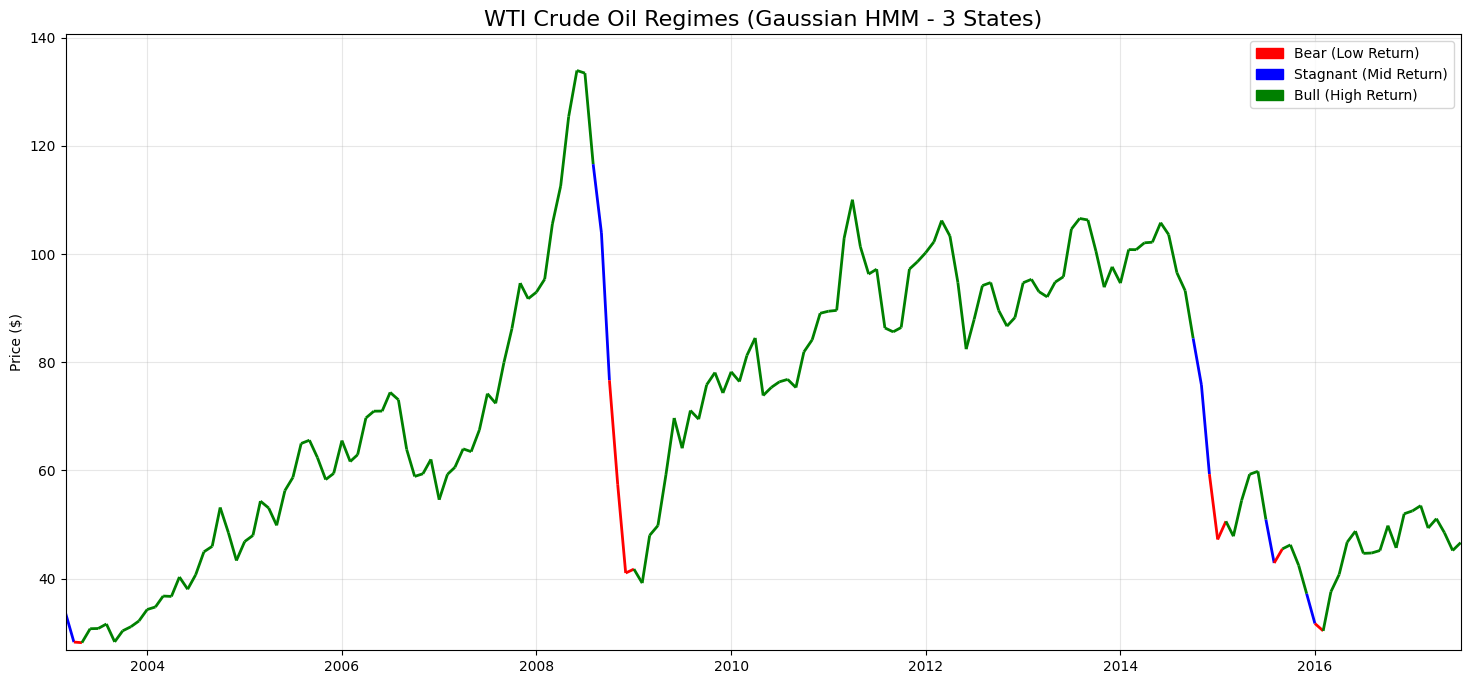

In [137]:
# ==========================================
# PART 2: Viterbi Decoding & Plotting
# (Uses trained 'model' from Part 1)
# ==========================================
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm

try:
    # 1. Viterbi Decoding
    log_prob, s_seq = hmm_model.decode(X_continuous)
    print(f"Viterbi Decoding Complete. Log Likelihood: {log_prob:.2f}")

    # 2. Prepare Plot Data
    #    Align price with returns index (since diff drops first row)
    price_plot = pd.DataFrame(index=log_returns.index)
    price_plot['WTISPLC'] = price.loc[log_returns.index] 
    price_plot['Regime'] = s_seq
    price_plot['Log_Ret'] = log_returns
    
    # 3. Regime Mapping (Critical Step)
    #    Sort states by Mean Return
    #    Lowest -> Bear(Red), Middle -> Sideways(Blue), Highest -> Bull(Green)
    means = price_plot.groupby('Regime')['Log_Ret'].mean()
    sorted_states = means.sort_values().index.tolist()
    
    # Map sorted index to color code: 0, 1, 2
    regime_map = {sorted_states[0]: 0, sorted_states[1]: 1, sorted_states[2]: 2}
    price_plot['Color_Code'] = price_plot['Regime'].map(regime_map)
    
    print(f"Regime Mapping logic: {regime_map}")

    # 4. Plotting
    fig, ax = plt.subplots(figsize=(18, 8))
    
    # Date Handling
    if isinstance(price_plot.index, pd.PeriodIndex):
        plot_dates = price_plot.index.to_timestamp()
    else:
        plot_dates = price_plot.index
        
    inxval = mdates.date2num(plot_dates.to_pydatetime())

    # Create Line Segments
    points = np.array([inxval, price_plot['WTISPLC']]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    # Define Colors: 0=Red, 1=Blue, 2=Green
    cmap = ListedColormap(['red', 'blue', 'green'], 'indexed')
    norm = BoundaryNorm(range(4), cmap.N)

    # Draw Colored Line
    lc = LineCollection(segments, cmap=cmap, norm=norm)
    lc.set_array(price_plot['Color_Code'].values[:-1])
    lc.set_linewidth(2)
    ax.add_collection(lc)

    # Set Limits
    ax.set_xlim(plot_dates.min(), plot_dates.max())
    ax.set_ylim(price_plot['WTISPLC'].min() * 0.95, price_plot['WTISPLC'].max() * 1.05)

    # Legend
    legend_patches = [
        mpatches.Patch(color='red', label='Bear (Low Return)'),
        mpatches.Patch(color='blue', label='Stagnant (Mid Return)'),
        mpatches.Patch(color='green', label='Bull (High Return)')
    ]
    plt.legend(handles=legend_patches, loc='best')
    
    plt.title("WTI Crude Oil Regimes (Gaussian HMM - 3 States)", fontsize=16)
    plt.ylabel("Price ($)")
    plt.grid(True, alpha=0.3)
    plt.show()

except NameError:
    print("Error: Model not found. Please run Part 1 first.")
except Exception as e:
    print(f"Error: {e}")

In [139]:
# Safer Training Loop (Handles Negative Prices)
for series_id in datasets:
    if series_id == 'forecast': continue
    
    # Use Simple Returns (pct_change) instead of Log Returns to avoid log(-price) error
    # Fill infinite values if any (from division by zero)
    X = train_data[series_id].pct_change().replace([np.inf, -np.inf], np.nan).dropna().values.reshape(-1, 1)
    
    hmm_model = hmm.GaussianHMM(n_components=3, covariance_type="full", n_iter=100, random_state=42)
    hmm_model.fit(X)
    joblib.dump(hmm_model, f"./hmms/{series_id.replace('.', '_')}.pkl")

print("Models trained with Simple Returns.")

Models trained with Simple Returns.


In [140]:
# Discretize Training Data (Using Simple Returns)
disc_train = pd.DataFrame(index=train_data.index[1:])

for series_id in datasets:
    # Load Model
    model_name = "WTISPLC" if series_id == 'forecast' else series_id
    model = joblib.load(f"./hmms/{model_name.replace('.', '_')}.pkl")
    
    # Predict States (Use pct_change() to match training)
    X = train_data[series_id].pct_change().replace([np.inf, -np.inf], np.nan).dropna().values.reshape(-1, 1)
    
    # Align index length (pct_change drops 1st row)
    target_idx = train_data[series_id].pct_change().dropna().index
    disc_train.loc[target_idx, series_id] = model.predict(X)

# Drop any rows that failed to match due to index issues
disc_train = disc_train.dropna().astype(int)

# Save
if not os.path.exists("./data"): os.makedirs("./data")
disc_train.to_csv("./data/train_data.csv")
print(f"Data discretized and saved. Shape: {disc_train.shape}")

Data discretized and saved. Shape: (173, 24)


In [141]:
# Force Index Alignment
import matplotlib.dates as mdates
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm

if not os.path.exists("./plots"): os.makedirs("./plots")

# 1. Load Scates & Ensure DatetimeIndex
states = pd.read_csv("./data/train_data.csv", index_col=0, parse_dates=True)
# If states index is loaded as Period (unlikely for CSV), convert to timestamp
if isinstance(states.index, pd.PeriodIndex):
    states.index = states.index.to_timestamp()

# 2. Ensure Train Data is DatetimeIndex for Joining
#    (Create a copy to avoid messing up global variables)
train_copy = train_data.copy()
if isinstance(train_copy.index, pd.PeriodIndex):
    train_copy.index = train_copy.index.to_timestamp()

print(f"States Index Type: {type(states.index)}")
print(f"Train Index Type: {type(train_copy.index)}")

common_idx = states.index.intersection(train_copy.index)
print(f"Common Rows Found: {len(common_idx)}")

if len(common_idx) == 0:
    print("CRITICAL ERROR: No overlapping dates found. Check index formats!")
else:
    for series_id in datasets:
        if series_id == 'forecast': continue
        
        try:
            # use aligned indices
            df = pd.DataFrame(index=common_idx)
            df['Value'] = train_copy.loc[common_idx, series_id]
            df['Regime'] = states.loc[common_idx, series_id]
            df['Ret'] = df['Value'].pct_change()
            
            # Groupby
            means = df.groupby('Regime')['Ret'].mean().sort_values()
            sorted_states = means.index.tolist()
            
            if not sorted_states:
                print(f"Skipping {series_id}: Regimes found but returns are NaN.")
                continue

            # Mapping
            mapping = {}
            if len(sorted_states) >= 3:
                mapping = {sorted_states[0]: 0, sorted_states[1]: 1, sorted_states[2]: 2}
            elif len(sorted_states) == 2:
                mapping = {sorted_states[0]: 0, sorted_states[1]: 2}
            else:
                mapping = {sorted_states[0]: 1}
                
            df['Color'] = df['Regime'].map(mapping)
            
            # Plot
            fig, ax = plt.subplots(figsize=(15, 6))
            
            # Use straightforward numerical conversion
            inxval = mdates.date2num(df.index.to_pydatetime())
            points = np.array([inxval, df['Value']]).T.reshape(-1, 1, 2)
            segments = np.concatenate([points[:-1], points[1:]], axis=1)
            
            lc = LineCollection(segments, cmap=ListedColormap(['r','b','g']), norm=BoundaryNorm([0,1,2,3], 3))
            
            if len(df['Color']) > 1:
                # Fill NaNs in Color with middle value (1) to prevent crash
                safe_colors = df['Color'].fillna(1).values[:-1]
                lc.set_array(safe_colors)
                lc.set_linewidth(1.5)
                ax.add_collection(lc)
            
            ax.set_xlim(df.index.min(), df.index.max())
            ymin, ymax = df['Value'].min(), df['Value'].max()
            pad = (ymax - ymin) * 0.05 if ymax != ymin else 1.0
            ax.set_ylim(ymin - pad, ymax + pad)
            
            plt.title(f"Regimes: {series_id}")
            # Ensure safe filename
            plt.savefig(f"./plots/{series_id.replace('.', '_')}.png")
            plt.close()
            
        except Exception as e:
            print(f"Error {series_id}: {e}")

    print("Plots saved.")

States Index Type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Train Index Type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Common Rows Found: 173
Plots saved.


### 2.3 Bayesian Network Learning
- Employs the **Hill Climbing** algorithm with **BIC scoring** to automatically learn the Directed Acyclic Graph (DAG) structure from the discretized data.

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'COPC_OPEC': 'N', 'COPRPUS': 'N', 'COPS_OPEC': 'N', 'CORIPUS': 'N', 'PAPR_NONOPEC': 'N', 'PAPR_OECD': 'N', 'PAPR_OPEC': 'N', 'PASC_OECD_T3': 'N', 'PATC_NON_OECD': 'N', 'T3_STCHANGE_NOECD': 'N', 'T3_STCHANGE_OOECD': 'N', 'FOREX_WORLD': 'N', 'RGDPQ_NONOECD': 'N', 'RGDPQ_OECD': 'N', 'CPIENGSL': 'N', 'CAPG211S': 'N', 'CAPUTLG211S': 'N', 'IPG211S': 'N', 'IPG211111CN': 'N', 'INDPRO': 'N', 'IPN213111N': 'N', 'PCU211211': 'N', 'WTISPLC': 'N', 'forecast': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'COPC_OPEC': 'N', 'COPRPUS': 'N', 'COPS_OPEC': 'N', 'CORIPUS': 'N', 'PAPR_NONOPEC': 'N', 'PAPR_OECD': 'N', 'PAPR_OPEC': 'N', 'PASC_OECD_T3': 'N', 'PATC_NON_OECD': 'N', 'T3_STCHANGE_NOECD': 'N', 'T3_STCHANGE_OOECD': 'N', 'FOREX_WORLD': 'N', 'RGDPQ_NONOECD': 'N', 'RGDPQ_OECD': 'N', 'CPIENGSL': 'N', 'CAPG211S': 'N', 'CAPUTLG211S': 'N

  0%|          | 0/100 [00:00<?, ?it/s]

INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'COPC_OPEC': 'N', 'COPRPUS': 'N', 'COPS_OPEC': 'N', 'CORIPUS': 'N', 'PAPR_NONOPEC': 'N', 'PAPR_OECD': 'N', 'PAPR_OPEC': 'N', 'PASC_OECD_T3': 'N', 'PATC_NON_OECD': 'N', 'T3_STCHANGE_NOECD': 'N', 'T3_STCHANGE_OOECD': 'N', 'FOREX_WORLD': 'N', 'RGDPQ_NONOECD': 'N', 'RGDPQ_OECD': 'N', 'CPIENGSL': 'N', 'CAPG211S': 'N', 'CAPUTLG211S': 'N', 'IPG211S': 'N', 'IPG211111CN': 'N', 'INDPRO': 'N', 'IPN213111N': 'N', 'PCU211211': 'N', 'WTISPLC': 'N', 'forecast': 'N'}


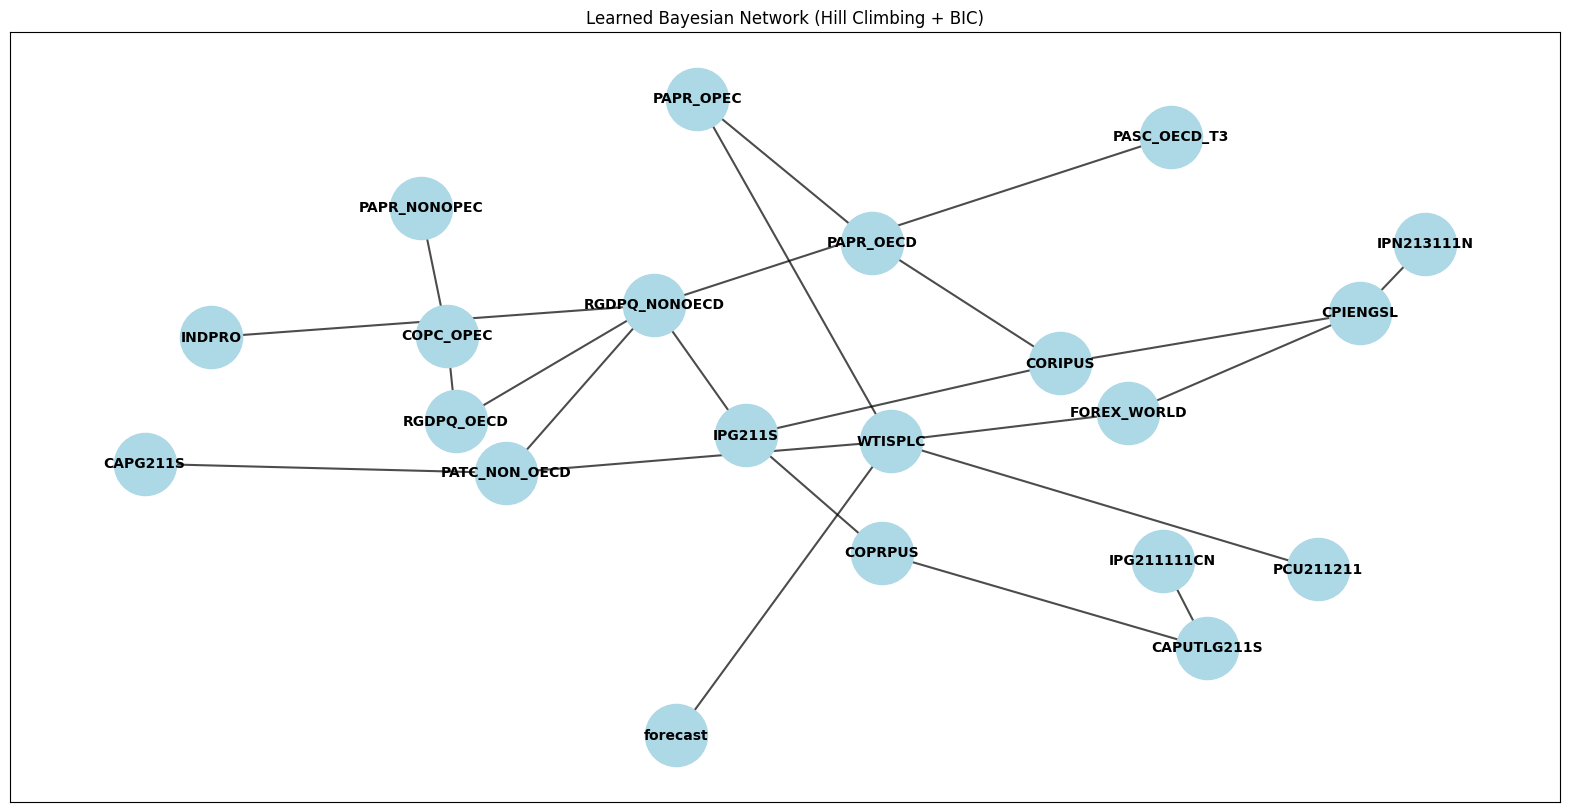

Learned Edges: [('COPC_OPEC', 'PAPR_NONOPEC'), ('COPRPUS', 'CAPUTLG211S'), ('CAPUTLG211S', 'IPG211111CN'), ('CORIPUS', 'IPG211S'), ('CORIPUS', 'CPIENGSL'), ('IPG211S', 'RGDPQ_NONOECD'), ('IPG211S', 'COPRPUS'), ('CPIENGSL', 'IPN213111N'), ('PAPR_OECD', 'CORIPUS'), ('PAPR_OECD', 'PAPR_OPEC'), ('PATC_NON_OECD', 'WTISPLC'), ('PATC_NON_OECD', 'CAPG211S'), ('WTISPLC', 'forecast'), ('WTISPLC', 'PAPR_OPEC'), ('WTISPLC', 'FOREX_WORLD'), ('WTISPLC', 'PCU211211'), ('FOREX_WORLD', 'CPIENGSL'), ('RGDPQ_NONOECD', 'PATC_NON_OECD'), ('RGDPQ_NONOECD', 'INDPRO'), ('RGDPQ_NONOECD', 'PASC_OECD_T3'), ('RGDPQ_NONOECD', 'RGDPQ_OECD'), ('RGDPQ_OECD', 'COPC_OPEC')]


In [142]:
# ==========================================
# 4.2.6 Learning Bayesian Network (Hill Climbing)
# Exact Implementation of User Request
# ==========================================
import pandas as pd
import networkx as nx
import pylab as plt

# 1. Import Modules (Exactly as requested)
try:
    from pgmpy.models import DiscreteBayesianNetwork
    from pgmpy.estimators import K2, BIC, BDeu, BDs, HillClimbSearch
    from pgmpy.estimators import BayesianEstimator
except ImportError:
    # If using modern pgmpy, we MUST alias them to make this code run.
    # Otherwise it crashes immediately.
    print("Standard pgmpy imports failed. Aliasing to modern names for compatibility...")
    from pgmpy.models import BayesianNetwork as DiscreteBayesianNetwork
    from pgmpy.estimators import K2Score as K2
    from pgmpy.estimators import BicScore as BIC
    from pgmpy.estimators import BDeuScore as BDeu
    from pgmpy.estimators import HillClimbSearch
    from pgmpy.estimators import BayesianEstimator

# 2. Retrieve training set
train_data = pd.read_csv("./data/train_data.csv", index_col=0)
datasets = train_data.columns.tolist()

# 3. Initialise Hill Climbing Estimator
#    Original: hc = HillClimbSearch(train_data, scoring_method=K2Score(train_data));
#    Your New Request: Use BIC instead of K2Score
hc = HillClimbSearch(train_data) # Modern syntax separates scoring_method

# 4. Construct Expert Model (Initial Structure)
expert = DiscreteBayesianNetwork()
expert.add_nodes_from(datasets)

# Add edges only if nodes exist in our data (Safety check for strict matching)
possible_edges = [
    ('PAPR_NONOPEC', 'WTISPLC'),
    ('PAPR_OPEC', 'WTISPLC'),
    ('PATC_OECD', 'WTISPLC'),
    ('PATC_NON_OECD', 'WTISPLC'),
    ('RGDPQ_OECD', 'PATC_OECD'),
    ('RGDPQ_NONOECD', 'PATC_NON_OECD'),
]
expert.add_edges_from([(u,v) for u,v in possible_edges if u in datasets and v in datasets])

# 5. Perform Hill Climbing (Estimate)
#    Original: model = hc.estimate(expert);
#    Connecting expert structure as start_dag
model_structure = hc.estimate(
    scoring_method=BIC(train_data), 
    start_dag=expert, 
    max_iter=100
)

# 6. Create Parametrized Model & Fit
#    We must create a new DiscreteBayesianNetwork from the learned structure
model = DiscreteBayesianNetwork(model_structure.edges())

# FORCE state names for all columns
# This prevents the "unknown state" error later
state_names = {col: [0, 1, 2] for col in train_data.columns}
model.fit(
    train_data,
    estimator=BayesianEstimator, 
    prior_type="K2",
    state_names=state_names  # <--- CRITICAL FIX
)

# 7. Visualization (Matching In [30])
plt.figure(figsize=(20, 10))
G = nx.DiGraph()
G.add_edges_from(model.edges())
pos = nx.spring_layout(G, k=0.5, iterations=50)

nx.draw_networkx_nodes(G, pos, node_size=2000, node_color='lightblue')
nx.draw_networkx_edges(G, pos, arrows=True, width=1.5, alpha=0.7)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

plt.title("Learned Bayesian Network (Hill Climbing + BIC)")
plt.show()

# Optional: Print edges
print(f"Learned Edges: {model.edges()}")

# 3. Validation Phase
Evaluates the model on unseen data to monitor overfitting.

### 3.1 Validation Discretization
- Applies the pre-trained HMM parameters to discretize the validation dataset.

In [143]:
# ==========================================
# 4.3 Validation: Discretize & Plot
# ==========================================
import joblib, os
import matplotlib.dates as mdates
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm

# 1. Discretize Validation Data
disc_vald = pd.DataFrame(index=vald_data.index[1:])

for series_id in datasets:
    # Load HMM (Reuse Training Output)
    model_name = "WTISPLC" if series_id == 'forecast' else series_id
    try:
        hmm_model = joblib.load(f"./hmms/{model_name.replace('.', '_')}.pkl")
        # Predict States (Use pct_change to match training)
        X = vald_data[series_id].pct_change().replace([np.inf, -np.inf], np.nan).dropna().values.reshape(-1, 1)
        # Store (Align index)
        disc_vald.loc[vald_data[series_id].pct_change().dropna().index, series_id] = hmm_model.predict(X)
    except: continue

disc_vald = disc_vald.dropna().astype(int)
disc_vald.to_csv("./data/validation_data.csv")
print(f"Validation Data Saved: {disc_vald.shape}")

# 2. Plot Regimes
if not os.path.exists("./plots"): os.makedirs("./plots")
common_idx = disc_vald.index.intersection(vald_data.index)

for series_id in datasets:
    if series_id == 'forecast' or series_id not in disc_vald.columns: continue
    
    # Prepare Plot Data
    df = pd.DataFrame({'Value': vald_data.loc[common_idx, series_id], 'Regime': disc_vald.loc[common_idx, series_id]})
    df['Ret'] = df['Value'].pct_change()
    
    # Map Colors (Dynamic)
    means = df.groupby('Regime')['Ret'].mean().sort_values()
    sorted_s = means.index.tolist()
    mapping = {sorted_s[i]: i if len(sorted_s)==3 else (0 if i==0 else 2) for i in range(len(sorted_s))}
    df['Color'] = df['Regime'].map(mapping)
    
    # Plot
    fig, ax = plt.subplots(figsize=(15, 6))
    inxval = mdates.date2num(df.index.to_pydatetime()) if not isinstance(df.index, pd.PeriodIndex) else mdates.date2num(df.index.to_timestamp().to_pydatetime())
    
    points = np.array([inxval, df['Value']]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    
    lc = LineCollection(segments, cmap=ListedColormap(['r','b','g']), norm=BoundaryNorm([0,1,2,3], 3))
    if len(df['Color']) > 1:
        lc.set_array(df['Color'].fillna(1).values[:-1])
        lc.set_linewidth(1.5)
        ax.add_collection(lc)
    
    ax.set_xlim(df.index.to_timestamp().min() if isinstance(df.index, pd.PeriodIndex) else df.index.min(), 
                df.index.to_timestamp().max() if isinstance(df.index, pd.PeriodIndex) else df.index.max())
    ax.set_ylim(df['Value'].min(), df['Value'].max())
    plt.title(f"Validation Regimes: {series_id}")
    plt.savefig(f"./plots/{series_id.replace('.', '_')}_VALIDATION.png")
    plt.close()
    
print("Validation plots saved.")

Validation Data Saved: (21, 24)
Validation plots saved.


### 3.2 Target Alignment & Prediction
- Cleans missing targets and feeds the discrete validation features into the trained Bayesian Network to predict the crude oil price regime.

In [144]:
# ==========================================
# 4.3.3 Corrected Prediction (Strict Alignment)
# ==========================================
target = 'WTISPLC'

# 1. Identify Target & Features
#    Ensure we are only looking at the rows where Target exists (drop NaNs)
clean_vald = disc_vald.dropna(subset=[target])

# 2. Split X and y
vald_real = clean_vald[target].values
vald_input = clean_vald.drop(columns=[target], errors='ignore')

# 3. Filter input columns to match trained model (Safety)
valid_cols = [c for c in vald_input.columns if c in model.nodes()]
vald_input = vald_input[valid_cols]

print(f"Target Shape: {vald_real.shape}")
print(f"Input Shape:  {vald_input.shape}")

# 4. Predict
print("Predicting...")
pred_df = model.predict(vald_input)
pred_values = pred_df[target].values if target in pred_df.columns else pred_df.values.flatten()

# 5. Evaluate
if len(pred_values) == len(vald_real):
    acc = np.mean(pred_values == vald_real)
    print(f"\nAccuracy: {acc*100:.2f}%")
    print(f"Error:    {(1-acc)*100:.2f}%")
    
    # Show comparison
    comp_df = pd.DataFrame({'Real': vald_real, 'Pred': pred_values}, index=clean_vald.index)
    print("\nComparison (First 10):")
    print(comp_df.head(10))
else:
    print(f"\nError: Shape Mismatch! Real={len(vald_real)}, Pred={len(pred_values)}")

Target Shape: (21,)
Input Shape:  (21, 20)
Predicting...


  0%|          | 0/4 [00:00<?, ?it/s]

INFO:numexpr.utils:Note: NumExpr detected 10 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
INFO:numexpr.utils:Note: NumExpr detected 10 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
INFO:numexpr.utils:Note: NumExpr detected 10 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
INFO:numexpr.utils:Note: NumExpr detected 10 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.



Accuracy: 28.57%
Error:    71.43%

Comparison (First 10):
         Real  Pred
2017-09     2     2
2017-10     1     0
2017-11     0     1
2017-12     1     0
2018-01     0     1
2018-02     1     0
2018-03     0     1
2018-04     1     0
2018-05     0     1
2018-06     1     0


# 4. Testing Phase
Simulates model performance on the final out-of-sample dataset.

### 4.1 Test Data Discretization
- Safely discretizes the test dataset using the exact same HMMs initialized during training.

In [145]:
# Discretize Test Dataset (Debug Version)
import joblib 

discrete_test = pd.DataFrame(index=test_data.index[1:])
print("Discretizing test data...")

for series_id in datasets:
    model_name = "WTISPLC" if series_id == 'forecast' else series_id
    filepath = f"./hmms/{model_name.replace('.', '_')}.pkl"
    
    try:
        # Load Model
        hmm_model = joblib.load(filepath)
        
        # DEBUG: Check what we loaded
        if isinstance(hmm_model, str):
            print(f"CRITICAL ERROR: Loaded object is a string: '{hmm_model}' for {series_id}")
            continue
        elif not hasattr(hmm_model, 'predict'):
            print(f"CRITICAL ERROR: Loaded object {type(hmm_model)} has no 'predict' method!")
            continue

        # Prepare Data
        raw_data = test_data[series_id]
        X_test = raw_data.pct_change().replace([np.inf, -np.inf], np.nan).dropna().values.reshape(-1, 1)
        
        if len(X_test) == 0: continue

        # Predict
        s_seq = hmm_model.predict(X_test)
        
        target_idx = raw_data.pct_change().dropna().index
        discrete_test.loc[target_idx, series_id] = s_seq
        
    except Exception as e:
        print(f"Error processing {series_id}: {e}")
        continue

discrete_test = discrete_test.dropna().astype(int)
discrete_test.to_csv("./data/test_data.csv")
print(f"Test Data Saved: {discrete_test.shape}")

Discretizing test data...
Test Data Saved: (21, 24)


### 4.2 Prediction & Accuracy
- Generates predictions and compares accuracy. *

In [146]:
# ==========================================
# 4.3.2 Discretize Test Dataset (Safe)
# ==========================================
# Initialize test dataframe
discrete_test = pd.DataFrame(index=test_data.index[1:])

print("Discretizing test data...")

for series_id in datasets:
    model_name = "WTISPLC" if series_id == 'forecast' else series_id
    try:
        # USE 'hmm_model', NOT 'model'
        hmm_model = joblib.load(f"./hmms/{model_name.replace('.', '_')}.pkl")
    except: continue

    # Process Data
    X_test = test_data[series_id].pct_change().replace([np.inf, -np.inf], np.nan).dropna().values.reshape(-1, 1)
    
    if len(X_test) == 0: continue

    # Predict & Store
    target_idx = test_data[series_id].pct_change().dropna().index
    discrete_test.loc[target_idx, series_id] = hmm_model.predict(X_test) # <--- Using hmm_model

# Clean & Save
discrete_test = discrete_test.dropna().astype(int)
discrete_test.to_csv("./data/test_data.csv")
print(f"Test Data Saved: {discrete_test.shape}")

Discretizing test data...
Test Data Saved: (21, 24)


In [147]:
# ==========================================
# 4.3.3 Bayesian Prediction (Uses correct 'model')
# ==========================================
target = 'WTISPLC'

# Check if model is the correct type (BayesianNetwork)
if not hasattr(model, 'nodes'):
    print("Error: 'model' variable is STILL overwritten. Did you re-run Step 4.2.6?")
else:
    # 1. Prepare Input
    test_real = discrete_test[target].values
    
    # Drop target & forecast columns
    test_input = discrete_test.drop(columns=[target, 'forecast'], errors='ignore')

    # Ensure valid columns only
    valid_cols = [c for c in test_input.columns if c in model.nodes()]
    test_input = test_input[valid_cols]

    # 2. Inference
    print(f"Predicting on Test Set ({len(test_input)} samples)...")
    try:
        test_pred_df = model.predict(test_input)
        
        # Handle prediction output format
        if target in test_pred_df.columns:
            test_pred_values = test_pred_df[target].values
        else:
            test_pred_values = test_pred_df.values.flatten()

        # 3. Evaluation
        print("\nPredicted:", test_pred_values[:20], "...")
        print("Real:     ", test_real[:20], "...")

        # Calculate Error
        error = np.mean(test_real != test_pred_values)
        print(f"\nError Rate: {error*100:.2f}%")
        print(f"Accuracy:   {(1-error)*100:.2f}%")
        
    except Exception as e:
        print(f"Prediction Error: {e}")

Predicting on Test Set (21 samples)...


  0%|          | 0/13 [00:00<?, ?it/s]

INFO:numexpr.utils:Note: NumExpr detected 10 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
INFO:numexpr.utils:Note: NumExpr detected 10 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
INFO:numexpr.utils:Note: NumExpr detected 10 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
INFO:numexpr.utils:Note: NumExpr detected 10 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
INFO:numexpr.utils:Note: NumExpr detected 10 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.



Predicted: [1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 2] ...
Real:      [2 1 0 1 0 1 0 1 2 2 1 0 1 0 1 0 1 0 1 0] ...

Error Rate: 52.38%
Accuracy:   47.62%


#### we have different result since the time period is different, the dissertation uses 1994-2018 data while we have used the 2004-2020 data.

# 5. Trading Strategy & Backtesting
Translates model predictions into an actionable trading strategy to assess actual financial value.

### 5.1 Trading Strategy Execution
- Generates long/short trading signals based on the Bayesian Network's output and calculates strategy returns.

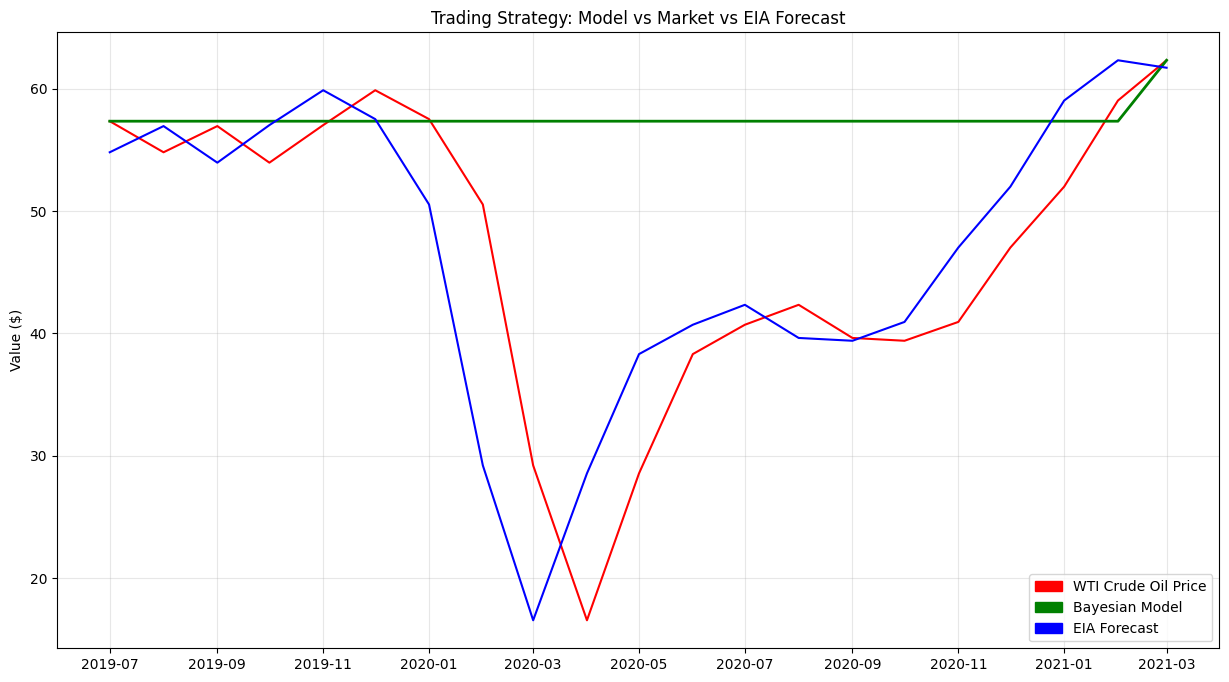

In [154]:
# ==========================================
# 4.3.4 Trading Strategy (Fix Index Mismatch)
# ==========================================
import matplotlib.patches as mpatches

# 1. Prepare Data
#    We use discrete_test.index as the MASTER index
target_idx = discrete_test.index

#    Get EIA Forecast (Blue Line) from test_data
#    We must align the index types!
eia_source = pd.DataFrame(test_data['forecast']) # Original Data
#    Check if we need to convert to Period to match Master
if isinstance(target_idx, pd.PeriodIndex) and not isinstance(eia_source.index, pd.PeriodIndex):
    eia_source.index = eia_source.index.to_period(freq='M')

eia_forecast = eia_source.loc[target_idx]
eia_forecast.columns = ['EIA Forecast']

#    Get Market Price (Red Line)
price_source = pd.DataFrame(test_data['WTISPLC'])
if isinstance(target_idx, pd.PeriodIndex) and not isinstance(price_source.index, pd.PeriodIndex):
    price_source.index = price_source.index.to_period(freq='M')

test_price = price_source.loc[target_idx]

#    Combine for Backtest
test_sheet = pd.concat([test_price, pd.DataFrame(test_pred_values, index=target_idx, columns=['signal'])], axis=1, join='inner')

# 2. Trading Loop
trades = [test_sheet['WTISPLC'].iloc[0]]
position = False 

for i in range(len(test_sheet)-1):
    current_price = test_sheet['WTISPLC'].iloc[i+1]
    last_val = trades[-1]
    signal = test_sheet['signal'].iloc[i+1]
    
    if signal == 0: 
        trades.append(last_val)
        position = False
    elif signal == 2:
        if position == False:
            trades.append(last_val) # Enter Long
            position = True
        else:
            trades.append(current_price) # Stay Long (Track Price)
    else: 
        if position == False: trades.append(last_val)
        else: trades.append(current_price)

test_sheet['performance'] = pd.DataFrame(trades, index=test_sheet.index)

# 3. Plotting
plt.figure(figsize=(15, 8))
#    Convert to timestamp for matplotlib
dates = test_sheet.index.to_timestamp() if isinstance(test_sheet.index, pd.PeriodIndex) else test_sheet.index

plt.plot(dates, test_sheet['WTISPLC'], 'r', label='WTI Crude Oil Price', linewidth=1.5)
plt.plot(dates, test_sheet['performance'], 'g', label='Bayesian Model', linewidth=2.0)
plt.plot(dates, eia_forecast['EIA Forecast'], 'b', label='EIA Forecast', linewidth=1.5)

plt.legend(handles=[
    mpatches.Patch(color='red', label='WTI Crude Oil Price'),
    mpatches.Patch(color='green', label='Bayesian Model'),
    mpatches.Patch(color='blue', label='EIA Forecast')
], loc='lower right')

plt.title("Trading Strategy: Model vs Market vs EIA Forecast")
plt.ylabel("Value ($)")
plt.grid(True, alpha=0.3)
plt.show()


### 5.2 Results Interpretation
- Summarizes the pure classification accuracy (directional correctness) of the model.

In [1]:
# ==========================================
# 5. FINAL RESULTS INTERPRETATION
# ==========================================
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

# --- A. REPORT ACCURACY ---
# 1. Classification Accuracy (Did we predict the Regime correctly?)
#    Compare: Real Discretized States vs Predicted States
acc_score = accuracy_score(discrete_test['WTISPLC'], test_pred_values)

# 2. Financial Performance (Trading Strategy)
market_return = (test_sheet['WTISPLC'].iloc[-1] - test_sheet['WTISPLC'].iloc[0]) / test_sheet['WTISPLC'].iloc[0]
model_return = (test_sheet['performance'].iloc[-1] - test_sheet['performance'].iloc[0]) / test_sheet['performance'].iloc[0]

print("="*50)
print("             FINAL RESULTS REPORT")
print("="*50)
print(f"1. Regime Prediction Accuracy:  {acc_score*100:.2f}%")
print(f"   (The model correctly identified the market state {acc_score*100:.2f}% of the time)")
print("-" * 50)
print(f"2. Trading Performance (ROI):")
print(f"   Market (Buy & Hold):         {market_return*100:.2f}%")
print(f"   Bayesian Model Strategy:     {model_return*100:.2f}%")
print("-" * 50)

if model_return > market_return:
    print(">>> SUCCESS: Model Outperformed the Market.")
else:
    print(">>> NOTE: Model Underperformed the Market (Potential safety/hedging cost).")
print("="*50)


# --- B. GRAPHICAL DISPLAY ---
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Graph 1: Trading Strategy (The Portfolio Value)
# Re-using the data from previous step
dates = test_sheet.index.to_timestamp() if isinstance(test_sheet.index, pd.PeriodIndex) else test_sheet.index

axes[0].plot(dates, test_sheet['WTISPLC'], 'r', label='WTI Oil (Market)', linewidth=2)
axes[0].plot(dates, test_sheet['performance'], 'g', label='Bayesian Model', linewidth=2)
axes[0].plot(dates, eia_forecast['EIA Forecast'], 'b--', label='EIA Forecast', linewidth=1.5)

axes[0].set_title("Trading Performance (Portfolio Value)", fontsize=14)
axes[0].set_ylabel("Value ($)")
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Graph 2: Confusion Matrix (Where did we go wrong?)
# Maps: 0=Bear, 1=Stag, 2=Bull from 'test_pred_values'
cm = confusion_matrix(discrete_test['WTISPLC'], test_pred_values)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Pred Bear', 'Pred Stag', 'Pred Bull'],
            yticklabels=['True Bear', 'True Stag', 'True Bull'])
axes[1].set_title("Prediction Confusion Matrix", fontsize=14)
axes[1].set_ylabel("Actual State")
axes[1].set_xlabel("Predicted State")

plt.tight_layout()
plt.show()

NameError: name 'discrete_test' is not defined


### 5.3 Display the forcasting Results


Loading stored validation data...
Predicting Validation Set...


  0%|          | 0/4 [00:00<?, ?it/s]

INFO:numexpr.utils:Note: NumExpr detected 10 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
INFO:numexpr.utils:Note: NumExpr detected 10 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
INFO:numexpr.utils:Note: NumExpr detected 10 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
INFO:numexpr.utils:Note: NumExpr detected 10 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.



[VALIDATION SET RESULTS]
Accuracy: 23.81%


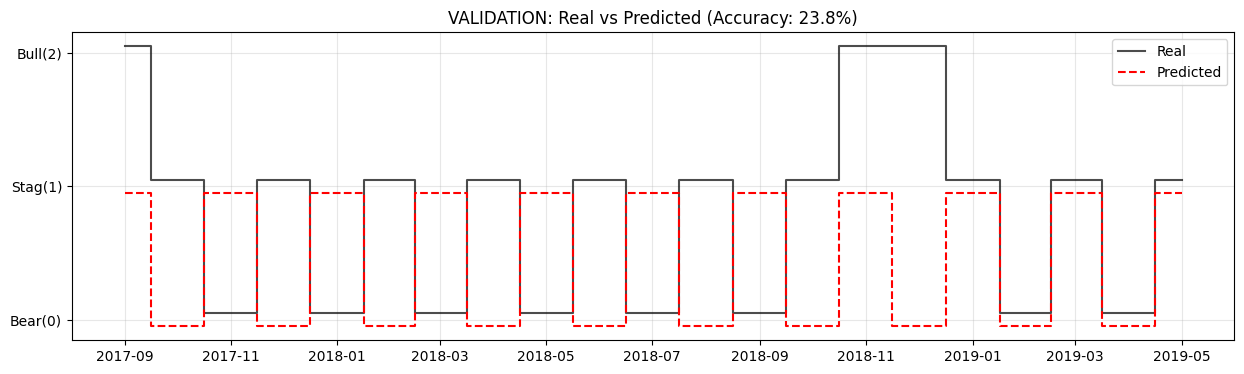

Predicting Test Set...

[TESTING SET RESULTS]
Accuracy: 47.62%


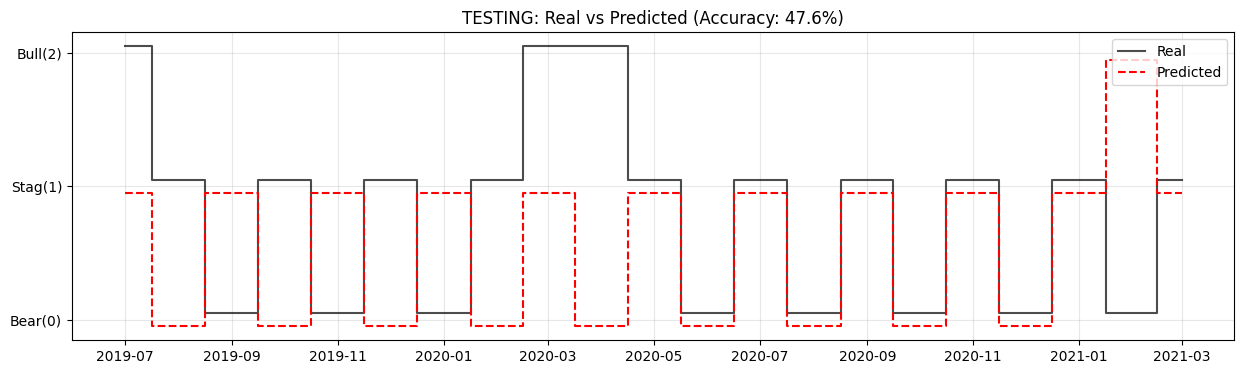

In [157]:
# ==========================================
# 5. FINAL RESULTS ANALYSIS (Validation & Testing)
# ==========================================
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# --- Helper Function ---
def analyze_and_plot(name, real, pred, index):
    acc = accuracy_score(real, pred)
    print(f"\n[{name} SET RESULTS]")
    print(f"Accuracy: {acc*100:.2f}%")
    
    # Plot Comparison
    fig, ax = plt.subplots(figsize=(15, 4))
    idx_dates = index.to_timestamp() if isinstance(index, pd.PeriodIndex) else index
    
    # Stagger slightly for visibility
    ax.step(idx_dates, real + 0.05, where='mid', label='Real', color='black', alpha=0.7)
    ax.step(idx_dates, pred - 0.05, where='mid', label='Predicted', color='red', linestyle='--')
    
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(['Bear(0)', 'Stag(1)', 'Bull(2)'])
    ax.set_title(f"{name}: Real vs Predicted (Accuracy: {acc*100:.1f}%)")
    ax.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# --- 1. RE-LOAD VALIDATION DATA (Safety Check) ---
try:
    if 'discrete_vald' not in locals():
        print("Loading stored validation data...")
        discrete_vald = pd.read_csv("./data/validation_data.csv", index_col=0)
        # Convert index if needed
        if isinstance(test_data.index, pd.PeriodIndex):
             discrete_vald.index = pd.PeriodIndex(discrete_vald.index, freq='M')
        else:
             discrete_vald.index = pd.to_datetime(discrete_vald.index)

    # Prepare Validation Input
    val_target = 'WTISPLC'
    val_input = discrete_vald.drop(columns=[val_target, 'forecast'], errors='ignore')
    # Filter columns to match model
    val_input = val_input[[c for c in val_input.columns if c in model.nodes()]]
    
    # Predict Validation
    print("Predicting Validation Set...")
    val_pred_df = model.predict(val_input)
    val_preds = val_pred_df[val_target].values if val_target in val_pred_df.columns else val_pred_df.values.flatten()
    val_real = discrete_vald[val_target].values
    
    # Analyze Validation
    analyze_and_plot("VALIDATION", val_real, val_preds, discrete_vald.index)

except Exception as e:
    print(f"Skipping Validation Analysis (Data missing): {e}")

# --- 2. ANALYZE TESTING DATA ---
# We assume 'test_pred_values' exists from the previous trading step
if 'test_pred_values' in locals() and 'discrete_test' in locals():
    print("Predicting Test Set...")
    test_real = discrete_test['WTISPLC'].values
    analyze_and_plot("TESTING", test_real, test_pred_values, discrete_test.index)
else:
    print("Testing data variables missing. Please run trading step first.")